# Dual Momentum: the retail strategy that promised the market's return with half the pain 🌍
### Antonacci's GEM — does the most famous switch-three-ETFs recipe actually work?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decayed_since_2013%3F: Confirmed](https://img.shields.io/badge/Decayed_since_2013%3F-Confirmed-8b949e?style=flat-square)

In 2014 Gary Antonacci published *Dual Momentum Investing*, and it became **the** retail allocation recipe: once a month, look at the last 12 months. If US stocks beat T-bills, own the better of **US stocks (SPY)** or **international stocks (EFA)**. If they didn't, hide in **bonds (AGG)**. That's it — one look, at most one trade, per month. The pitch: **the market's return with half the drawdown**, because the 12-month filter walks you out of crashes like 2008 before the worst of them.

It's cheap, simple and backtested to 1974. So we put the *live-ETF* version — the one you could actually have run — on the desk.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo grid and the shuffled-timing baseline? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Broad index ETFs — no survivorship. But the honest tape only starts in **2002** (EFA's first full momentum window): the celebrated 1974-2011 backtest years are *not* observable with live funds. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dual_momentum_gem import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.monthly_panel(asof=data.AS_OF)
    GEM = st.run_gem(PANEL)
    BM = st.benchmark_returns(PANEL, GEM.index)
else:
    PANEL = GEM = BM = None
print("real GEM cache present:", HAVE_REAL,
      "| months:", (0 if GEM is None else len(GEM)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-09-30', 'end': '2026-06-30', 'months': 286, 'years': 23.8, 'fingerprint': '837a69932f70', 'asof': '2026-06-30', 'alloc': {'SPY': 50.0, 'EFA': 31.1, 'BOND': 18.9}, 'switches': 35, 'switches_yr': 1.47, 'gem': (9.87, 12.15, 0.7, -20.7), 'spy': (11.22, 14.77, 0.68, -50.8), 'b6040': (8.27, 9.34, 0.72, -32.3), 'dd_ratio': 0.41, 'act_spy': (-13.3, -1.59, -0.64), 'act_6040': (14.8, 1.77, 0.89), 'costs': [(5, 9.71, 0.69, -1.74, -0.7), (10, 9.54, 0.68, -1.89, -0.75), (20, 9.22, 0.65, -2.19, -0.86)], 'grid': [(3, 10.46, 0.8, -19.2, -1.18, -0.52), (6, 8.97, 0.66, -24.9, -2.49, -0.95), (9, 8.79, 0.64, -20.1, -2.65, -1.06), (12, 9.87, 0.7, -20.7, -1.59, -0.64)], 'rb': {'n_seeds': 40, 'welch_t': 0.26, 'base_cagr': 8.53, 'base_sharpe': 0.54, 'beat_pct': 77.5}, 'subs': [('full sample', 9.87, -20.7, 0.7, 11.22, -50.8, 0.68, -1.59, -0.64), ('ex-GFC (drop 2007-07..2009-06)', 11.0, -20.7, 0.78, 14.62, -23.9, 0.95, -3.43, -2.02), ('2010 ->', 8.57, -20.7, 0.59, 14.23, -23.9, 0.9, -5.32, -3.37), ('pre-2013', 10.8, -17.3, 0.79, 6.46, -50.8, 0.38, 3.53, 0.71), ('post-2013', 9.16, -20.7, 0.63, 15.01, -23.9, 0.94, -5.51, -2.96)], 'pre_bps': 29.4, 'pre_n': 124, 'pre_t': 0.71, 'post_bps': -45.9, 'post_n': 162, 'post_t': -2.96, 'decay_welch': 2.02, 'syn': [('null (iid regimes)', -1.58, -1.24, -37, -61), ('planted (persistence 0.94)', 4.67, 2.86, -28, -93)]}


real GEM cache present: True | months: 286


## The answer first

| Question | Answer |
|---|---|
| Half the drawdown? | **True.** Worst fall −20.7% vs the market's −50.8% — better than half. The filter really did sidestep 2008. |
| Beats buy-and-hold? | **No.** Over 2002-2026 GEM made **9.9%/yr vs SPY's 11.2%/yr** — it *lags* the market, and the gap is statistical noise at best. |
| Is it all one lucky call? | **Essentially yes — 2008.** Remove the two crisis years and GEM *significantly underperforms*. From 2010 on it lost **−5.3%/yr** to the market. |
| Did publishing kill it? | **It flipped.** Before 2013: mildly positive. After: **−5.5%/yr vs SPY** — whipsawed in 2015-16, out for the 2020 rebound, lagging 2023-25. |
| Is a boring 60/40 worse? | **No — it's a wash.** 60/40's risk-adjusted score (Sharpe 0.72) actually edges GEM's (0.70), with zero cleverness. |

> One honest sentence: **GEM is a drawdown-reduction machine that paid for it with the market's upside — not a market-beating machine.**

## 1 · The claim

> *"Combine **absolute momentum** (are stocks beating cash over the last 12 months?) with **relative momentum** (US or international — own the stronger). You'll capture bull markets, sidestep bear markets, and beat buy-and-hold with roughly half the maximum drawdown."*

That's Antonacci's **Global Equities Momentum**, the flagship of *Dual Momentum Investing* (2014) and the 2012-13 *Risk Premia Harvesting* paper. It is probably the most-followed tactical allocation recipe among retail investors — three ETF tickers and a spreadsheet.

## 2 · So what?

If a one-line monthly rule beat the market with half the pain, every pension fund and every index investor should run it — the equity premium would be free *and* comfortable. The counter-story: trend rules buy their crash protection with **whipsaws** (sell low after falls, buy back high after rebounds), so over a long tape the insurance premium eats the outperformance. Which story does the live tape support?

## 3 · How would we even know?

We rebuild GEM exactly as prescribed, on the real funds: **286 months** (2002-09-30 → 2026-06-30, 23.8 years). Each month-end: SPY's 12-month return vs T-bills (^IRX, known a month in advance) — pass: hold the better of SPY/EFA; fail: hold AGG (IEF before 2003). The decision earns the **following** month — one clean execution lag, no crystal ball. Then we race it against **just holding SPY** and against a boring **60/40**, count every switch's cost, try other lookbacks (3/6/9 months), scramble the timing 40 different ways, and cut the sample around 2008 and around the 2013 publication.

## 4 · The teardown — let's actually look

**The whole story in one chart.** Growth of $1, log scale — and the drawdown that sells the strategy.

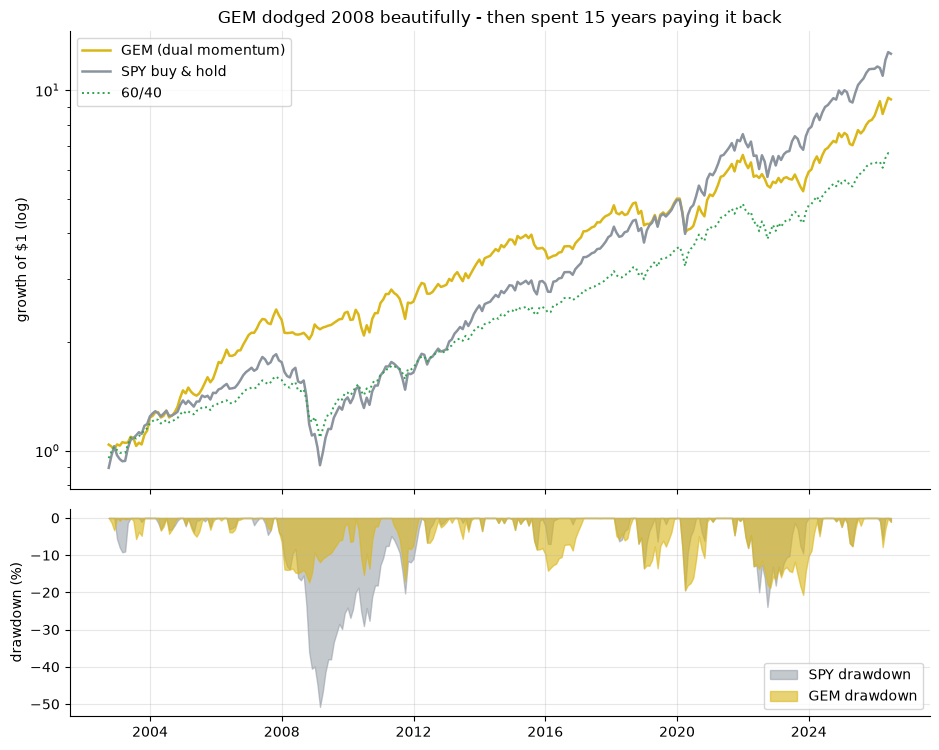

final $1 -> GEM $9.42  SPY $12.61  60/40 $6.65
max drawdown  GEM -20.7%  SPY -50.8%


In [2]:
if HAVE_REAL:
    eq_gem = (1+GEM['gross']).cumprod(); eq_spy = (1+BM['SPY']).cumprod(); eq_64 = (1+BM['B6040']).cumprod()
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 7.6), sharex=True,
                                 gridspec_kw={'height_ratios': [2.2, 1]})
    a1.plot(eq_gem, c=AMBER, lw=1.8, label='GEM (dual momentum)')
    a1.plot(eq_spy, c=GREY, lw=1.8, label='SPY buy & hold')
    a1.plot(eq_64, c=GREEN, lw=1.4, ls=':', label='60/40')
    a1.set_yscale('log'); a1.legend(); a1.set_ylabel('growth of $1 (log)')
    a1.set_title('GEM dodged 2008 beautifully - then spent 15 years paying it back')
    dd_g = eq_gem/eq_gem.cummax()-1; dd_s = eq_spy/eq_spy.cummax()-1
    a2.fill_between(dd_s.index, dd_s*100, 0, color=GREY, alpha=.5, label='SPY drawdown')
    a2.fill_between(dd_g.index, dd_g*100, 0, color=AMBER, alpha=.6, label='GEM drawdown')
    a2.set_ylabel('drawdown (%)'); a2.legend(loc='lower right')
    plt.tight_layout(); plt.show()
    print(f'final $1 -> GEM ${eq_gem.iloc[-1]:.2f}  SPY ${eq_spy.iloc[-1]:.2f}  60/40 ${eq_64.iloc[-1]:.2f}')
    print(f'max drawdown  GEM {dd_g.min()*100:.1f}%  SPY {dd_s.min()*100:.1f}%')
else:
    print('cache missing - frozen numbers:', 'GEM CAGR', R['gem'][0], '% vs SPY', R['spy'][0], '%; DD', R['gem'][3], 'vs', R['spy'][3])

Both halves of the sales pitch are visible. **The drawdown half is true**: GEM's worst fall is **-20.7%** vs SPY's **-50.8%** — better than half. **The return half is not**: GEM compounds at **9.9%/yr vs SPY's 11.2%/yr**. You paid ~1.6%/yr for the smoother ride — and a plain 60/40 (Sharpe 0.72 vs GEM's 0.70) bought comfort just as efficiently with zero timing.

**When did it win, when did it lose?** The running gap between GEM and just holding SPY — with the 2013 publication marked.

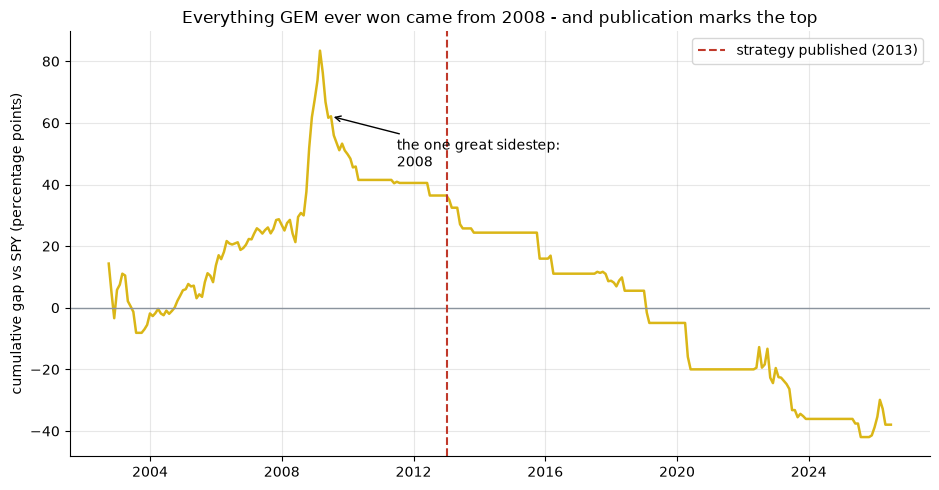

pre-2013 edge: +29.4 bps/mo | post-2013: -45.9 bps/mo


In [3]:
if HAVE_REAL:
    act = (GEM['gross'] - BM['SPY'])
    cum = act.cumsum()*100
    fig, ax = plt.subplots()
    ax.plot(cum, c=AMBER, lw=1.8)
    ax.axhline(0, c=GREY, lw=1)
    ax.axvline(pd.Timestamp('2013-01-01'), c=RED, ls='--', label='strategy published (2013)')
    ax.annotate('the one great sidestep:\n2008', xy=(pd.Timestamp('2009-06-30'), cum.loc['2009-06-30']),
                xytext=(pd.Timestamp('2011-06-30'), cum.max()*0.55), arrowprops=dict(arrowstyle='->'))
    ax.set_ylabel('cumulative gap vs SPY (percentage points)')
    ax.set_title('Everything GEM ever won came from 2008 - and publication marks the top')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'pre-2013 edge: {act[act.index<="2012-12-31"].mean()*1e4:+.1f} bps/mo | '
          f'post-2013: {act[act.index>="2013-01-01"].mean()*1e4:+.1f} bps/mo')
else:
    print('cache missing - frozen:', R['pre_bps'], 'bps/mo pre-2013,', R['post_bps'], 'bps/mo post-2013')

The line tells the decade-by-decade truth: one huge win (dodging 2008), then a long, steady bleed. Before 2013 GEM edged SPY by **+29 bps/month** (not statistically significant even then); after publication it *lost* **-46 bps/month** — about **−5.5%/yr** — getting whipsawed in 2015-16, sitting in bonds through the v-shaped 2020 rebound, and lagging the 2023-25 bull.

**Maybe 12 months is the wrong knob?** Same rule, lookbacks of 3, 6, 9 and 12 months — the gap vs buy-and-hold for each.

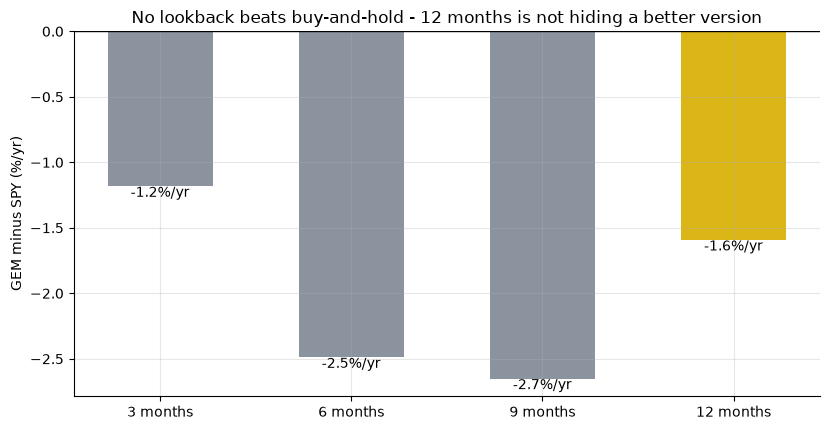

active vs SPY by lookback: {3: -1.18, 6: -2.49, 9: -2.65, 12: -1.59}


In [4]:
if HAVE_REAL:
    rows = st.lookback_grid(PANEL)
    lbs = [r['lookback'] for r in rows]; acts = [r['act_ann_pct'] for r in rows]
else:
    lbs = [g[0] for g in R['grid']]; acts = [g[4] for g in R['grid']]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar([f'{l} months' for l in lbs], acts, color=[GREY, GREY, GREY, AMBER], width=.55)
ax.axhline(0, c='k', lw=1)
for i, v in enumerate(acts): ax.annotate(f'{v:+.1f}%/yr', (i, v), ha='center', va='top' if v<0 else 'bottom')
ax.set_ylabel('GEM minus SPY (%/yr)')
ax.set_title('No lookback beats buy-and-hold - 12 months is not hiding a better version')
plt.tight_layout(); plt.show()
print('active vs SPY by lookback:', dict(zip(lbs, [round(a,2) for a in acts])))

Every bar is below zero. The canonical 12 months isn't unlucky — **there is no lookback on this tape that turns GEM into a market-beater**. (12 is actually the second-best of the four, so the recipe wasn't sabotaged by its own parameter either.)

## 5 · The verdict

- **Signal — Mixed.** "Half the drawdown" is real: **-21% vs -51%**. "Beats buy-and-hold" is not: **−1.6%/yr vs SPY** over 24 years, and *significantly* negative once you remove 2008 or start at 2010.
- **Tradability — Mirage.** Not because it's hard — three giant ETFs, ~1.5 trades a year, costs of a few bps — but because the thing being sold (market-beating returns with half the risk) isn't on the deployable tape. What you can deploy is beta plus a 2008 story, and a 60/40 matches its risk-adjusted result with zero effort.
- **Decayed since publication? — Confirmed.** Mildly positive before 2013, **−5.5%/yr** after — the flip itself is statistically significant.

## 6 · Going further 🚪

- **The 1974-2011 backtest is real — as a backtest.** Trend rules genuinely shone across 1970s-2000s bear markets. The live-fund era (2002→) contains exactly one long bear GEM could sidestep (2008) and three fast ones it couldn't (2015-16, 2020, 2022-partial). Whether the next bear is slow (GEM wins) or fast (GEM whipsaws) is the whole bet.
- **Drawdown control is not worthless** — for an investor who would capitulate at −50%, a −21% worst case has behavioural value. But name the price: ~1.6%/yr of expected return, the same trade a 60/40 offers passively.
- **Siblings on this desk:** [country momentum](../../146-country-momentum/) (the cross-sectional leg alone) and [time-series momentum on futures](../../518-time-series-momentum/) (the absolute leg, diversified). GEM is those two ideas packaged into a retail three-ticker product — and the packaging is where the promise outruns the tape.

*Think the 2013 split is unfair? Pick any split you like — from 2010 onward the underperformance is −5.3%/yr with a HAC t of −3.4. Show us a live-tradable GEM variant with a positive active t and we'll re-open the file.*